# MATH 70116, Deep Learning
Autumn 2026

Lecturer: Tom Hadfield

### Vanishing and Exploding Gradients

Vanishing and exploding gradients cause difficulties during neural network training.

Vanishing gradients lead to very slow (or zero) learning in earlier layers

Exploding gradients lead to unstable updates and diverging loss

Training may converge poorly or fail completely

Avoiding these problems requires careful tuning of learning rates and weight initialisation

The choice of activation function is important!

In [1]:
import numpy as np
import numpy.random as npr
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import sklearn
from sklearn.model_selection import train_test_split

In [ ]:
# !pip install scikit-learn
# %pip install scikit-learn

### Create a simple dataset

Binary classification dataset.

Keep the data simple so we can focus on the gradient behaviour.

Prevent data complexity from hiding gradient issues

In [2]:
np.random.seed(42)

X = np.random.randn(2000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
for xx in [X_train, X_test, y_train, y_test]:
    print(type(xx), xx.shape)

<class 'numpy.ndarray'> (1600, 2)
<class 'numpy.ndarray'> (400, 2)
<class 'numpy.ndarray'> (1600,)
<class 'numpy.ndarray'> (400,)


### Visualise the data

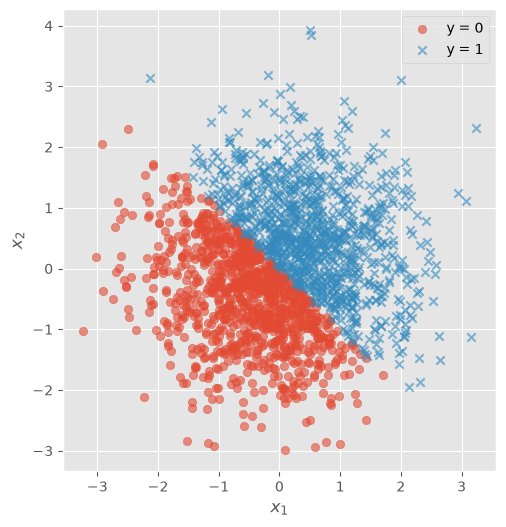

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', alpha=0.6, label='y = 0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], marker='x', alpha=0.6, label='y = 1')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal')
ax.legend()
plt.show()

### Compare Sigmoid and ReLU

Identical architecture, apart from the choice of activation function

Uses many layers to amplify vanishing gradient effects

### Train Model with Sigmoid Activation
Sigmoid has small derivatives

Gradients shrink as they move backward

Early layers learn very slowly

In [19]:
activation = nn.Sigmoid()
num_layers = 20
hidden_dim = 32

f_sigmoid = build_model(activation, num_layers, hidden_dim)

In [11]:
# print(f_sigmoid)

In [20]:
eta = 0.001
optimizer = torch.optim.Adam(f_sigmoid.parameters(), lr=eta)
loss_fn = nn.BCELoss()

In [21]:
epochs = 100

train_sigmoid = train_model(
    f_sigmoid,
    X_train,
    y_train,
    loss_fn,
    optimizer,
    epochs,
    batch_size=32,
    validation_split=0.2,
    verbose_every=1
)

n_total =  1600 n_val =  320 n_train =  1280
Epoch 1/100, loss: 0.6946, val_loss: 0.6938
Epoch 2/100, loss: 0.6944, val_loss: 0.6941
Epoch 3/100, loss: 0.6941, val_loss: 0.6934
Epoch 4/100, loss: 0.6933, val_loss: 0.6934
Epoch 5/100, loss: 0.6939, val_loss: 0.6930
Epoch 6/100, loss: 0.6936, val_loss: 0.6931
Epoch 7/100, loss: 0.6932, val_loss: 0.6943
Epoch 8/100, loss: 0.6943, val_loss: 0.6932
Epoch 9/100, loss: 0.6938, val_loss: 0.6936
Epoch 10/100, loss: 0.6938, val_loss: 0.6943
Epoch 11/100, loss: 0.6936, val_loss: 0.6932
Epoch 12/100, loss: 0.6937, val_loss: 0.6941
Epoch 13/100, loss: 0.6940, val_loss: 0.6943
Epoch 14/100, loss: 0.6932, val_loss: 0.6936
Epoch 15/100, loss: 0.6934, val_loss: 0.6936
Epoch 16/100, loss: 0.6937, val_loss: 0.6945
Epoch 17/100, loss: 0.6932, val_loss: 0.6935
Epoch 18/100, loss: 0.6938, val_loss: 0.6931
Epoch 19/100, loss: 0.6939, val_loss: 0.6944
Epoch 20/100, loss: 0.6935, val_loss: 0.6936
Epoch 21/100, loss: 0.6937, val_loss: 0.6941
Epoch 22/100, loss:

In [22]:
print(train_sigmoid.keys())

dict_keys(['loss', 'val_loss'])


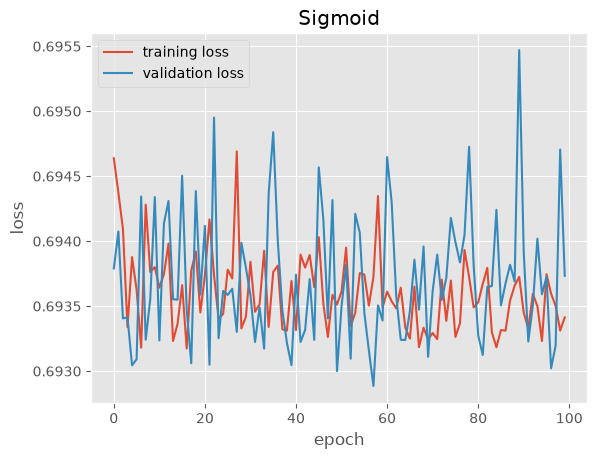

In [23]:
loss_vals = train_sigmoid["loss"]
val_loss_vals = train_sigmoid["val_loss"]
epoch_vals = range(len(loss_vals))

plt.plot(epoch_vals, loss_vals, label = "training loss")
plt.plot(epoch_vals, val_loss_vals, label = "validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Sigmoid")
plt.show()

ppred.shape =  (361201, 1)
ppred.shape =  (601, 601)
max =  0.5075513
min =  0.5075513


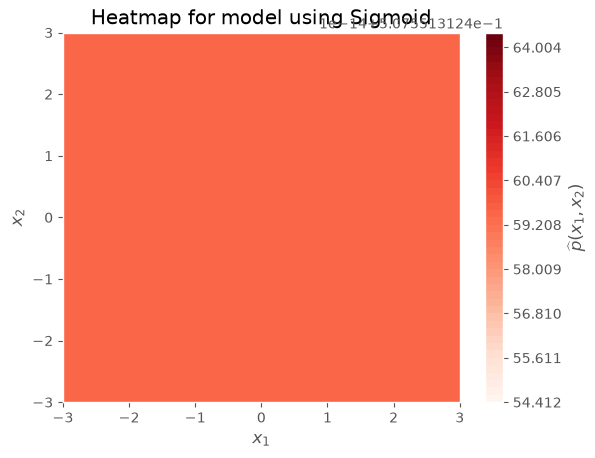

In [26]:
# num points in grid
this_num = 6 * 100 + 1

grid = np.linspace(-3., 3., num=this_num)
X_1g, X_2g = np.meshgrid(grid, grid)

X_1gf = np.reshape(X_1g, (this_num*this_num, 1))
X_2gf = np.reshape(X_2g, (this_num*this_num, 1))
Xf = np.concatenate((X_1gf, X_2gf), 1)

ppred = model_predict(f_sigmoid,Xf)

print("ppred.shape = ", ppred.shape)

ppred = np.reshape(ppred,(this_num, this_num))
print("ppred.shape = ", ppred.shape)
print("max = ", np.max(ppred))
print("min = ", np.min(ppred))

plt.contourf(X_1g, X_2g, ppred, 50, cmap="Reds")
cbar = plt.colorbar()
cbar.ax.set_ylabel(r"$\widehat{p}(x_1,x_2)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Heatmap for model using Sigmoid")
plt.show()

### Train model with ReLU activation

ReLU is non-saturating

Preserves gradient magnitude

Enables faster and more stable learning

In [27]:
activation = nn.ReLU()
num_layers = 20
hidden_dim = 32

f_relu = build_model(activation, num_layers, hidden_dim)

In [ ]:
# print(f_relu)

In [28]:
eta = 0.001
optimizer = torch.optim.Adam(f_relu.parameters(), lr=eta)
loss_fn = nn.BCELoss()

In [29]:
epochs = 100

train_relu = train_model(
    f_relu,
    X_train,
    y_train,
    loss_fn,
    optimizer,
    epochs,
    batch_size=32,
    X_val=X_test,
    y_val=y_test, 
    verbose_every=1
)

Epoch 1/100, loss: 0.6941, val_loss: 0.6927
Epoch 2/100, loss: 0.6933, val_loss: 0.6932
Epoch 3/100, loss: 0.6934, val_loss: 0.6936
Epoch 4/100, loss: 0.6934, val_loss: 0.6933
Epoch 5/100, loss: 0.6934, val_loss: 0.6930
Epoch 6/100, loss: 0.6936, val_loss: 0.6931
Epoch 7/100, loss: 0.6932, val_loss: 0.6933
Epoch 8/100, loss: 0.6933, val_loss: 0.6932
Epoch 9/100, loss: 0.6933, val_loss: 0.6934
Epoch 10/100, loss: 0.6932, val_loss: 0.6933
Epoch 11/100, loss: 0.6935, val_loss: 0.6930
Epoch 12/100, loss: 0.6910, val_loss: 0.6085
Epoch 13/100, loss: 0.1298, val_loss: 0.0355
Epoch 14/100, loss: 0.0575, val_loss: 0.0367
Epoch 15/100, loss: 0.0374, val_loss: 0.0402
Epoch 16/100, loss: 0.0241, val_loss: 0.0137
Epoch 17/100, loss: 0.0234, val_loss: 0.0160
Epoch 18/100, loss: 0.0200, val_loss: 0.0176
Epoch 19/100, loss: 0.0108, val_loss: 0.0044
Epoch 20/100, loss: 0.0198, val_loss: 0.0100
Epoch 21/100, loss: 0.0112, val_loss: 0.0151
Epoch 22/100, loss: 0.0256, val_loss: 0.0196
Epoch 23/100, loss:

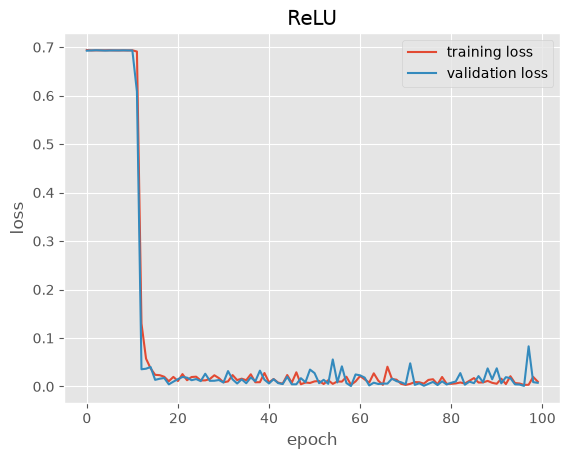

In [30]:
loss_vals = train_relu["loss"]
val_loss_vals = train_relu["val_loss"]
epoch_vals = range(len(loss_vals))

plt.plot(epoch_vals, loss_vals, label = "training loss")
plt.plot(epoch_vals, val_loss_vals, label = "validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("ReLU")
plt.show()

ppred.shape =  (601, 601)
max =  1.0
min =  0.0


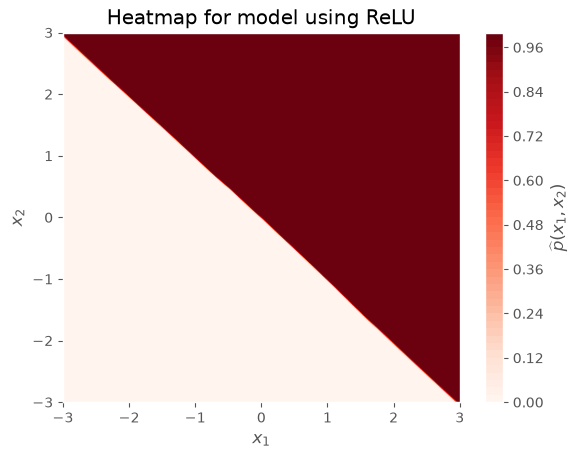

In [31]:
# num points in grid
this_num = 6 * 100 + 1

grid = np.linspace(-3., 3., num=this_num)
X_1g, X_2g = np.meshgrid(grid, grid)

X_1gf = np.reshape(X_1g, (this_num*this_num, 1))
X_2gf = np.reshape(X_2g, (this_num*this_num, 1))
Xf = np.concatenate((X_1gf, X_2gf), 1)

ppred = model_predict(f_relu,Xf)

ppred = np.reshape(ppred,(this_num, this_num))
print("ppred.shape = ", ppred.shape)
print("max = ", np.max(ppred))
print("min = ", np.min(ppred))

plt.contourf(X_1g, X_2g, ppred, 50, cmap="Reds")
cbar = plt.colorbar()
cbar.ax.set_ylabel(r"$\widehat{p}(x_1,x_2)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Heatmap for model using ReLU")
plt.show()

In [5]:
def build_model(activation = nn.Sigmoid(), num_layers=20, hidden_dim = 32):
    
    f = nn.Sequential()
    f.add_module("input", nn.Linear(2, hidden_dim))
    f.add_module("act_0", activation)
    
    for i in range(1,num_layers):
        layer_name = "dense" + str(i)
        act_name = "act" + str(i)
        f.add_module(layer_name, nn.Linear(hidden_dim, hidden_dim))
        f.add_module(act_name, activation)
        
    f.add_module("output", nn.Linear(hidden_dim, 1))
    f.add_module("act_output", nn.Sigmoid()) # final activation must be Sigmoid

    return f

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

def train_model(
    model,
    X,
    y,
    loss_fn,
    optimizer,
    epochs=100,
    batch_size=32,
    metrics=None,
    X_val=None,
    y_val=None,
    validation_split=0.0,   
    verbose_every=10,
    device=None,
):
    """
    Generic training loop for a PyTorch model.

    ... (same as before) ...

    validation_split : float in [0.0, 1.0)
        Fraction of (X, y) to hold out as validation data, taken from the
        END of the dataset (matching Keras's default behavior). Ignored if
        X_val and y_val are both explicitly provided.
    """
    if not (0.0 <= validation_split < 1.0):
        raise ValueError("validation_split must be in [0.0, 1.0)")

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    def to_tensor(a):
        if isinstance(a, np.ndarray):
            return torch.from_numpy(a).float()
        return a.float()

    X = to_tensor(X)
    y = to_tensor(y)

    # --- Handle validation_split (only if X_val/y_val not already given) ---
    if X_val is None and y_val is None and validation_split > 0.0:
        n_total = X.shape[0]
        n_val = int(round(n_total * validation_split))
        n_train = n_total - n_val

        X_val = X[n_train:]
        y_val = y[n_train:]
        X = X[:n_train]
        y = y[:n_train]
        print("n_total = ", n_total, "n_val = ", n_val, "n_train = ", n_train)

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    has_val = X_val is not None and y_val is not None
    if has_val:
        X_val = to_tensor(X_val).to(device)
        y_val = to_tensor(y_val).to(device)

    metrics = metrics or {}

    history = {"loss": []}
    history.update({name: [] for name in metrics})
    if has_val:
        history["val_loss"] = []
        history.update({f"val_{name}": [] for name in metrics})

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_metrics = {name: 0.0 for name in metrics}
        n_samples = 0

        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model(X_batch)
            y_batch = y_batch.unsqueeze(-1)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = X_batch.size(0)
            running_loss += loss.item() * bs
            for name, fn in metrics.items():
                running_metrics[name] += fn(y_pred, y_batch) * bs
            n_samples += bs

        epoch_loss = running_loss / n_samples
        #print("epoch = ", epoch, ", loss = ", epoch_loss) 
        history["loss"].append(epoch_loss)
        for name in metrics:
            val = running_metrics[name] / n_samples
            history[name].append(val)

        log_str = f"Epoch {epoch+1}/{epochs}, loss: {epoch_loss:.4f}"
        for name in metrics:
            log_str += f", {name}: {history[name][-1]:.4f}"

        if has_val:
            model.eval()
            with torch.no_grad():
                y_val_pred = model(X_val).squeeze()
                val_loss = loss_fn(y_val_pred, y_val).item()
                history["val_loss"].append(val_loss)
                #print("epoch = ", epoch, ", val_loss = ", val_loss) 
                log_str += f", val_loss: {val_loss:.4f}"
                for name, fn in metrics.items():
                    val_metric = fn(y_val_pred, y_val)
                    history[f"val_{name}"].append(val_metric)
                    log_str += f", val_{name}: {val_metric:.4f}"

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(log_str)

    return history

In [8]:
def model_predict(model, input_data):

	is_numpy_array = isinstance(input_data, np.ndarray)
	
	# 1. Make sure input_data is a float32 tensor
	if is_numpy_array:
		input_data = torch.from_numpy(input_data).float()
	else:
		input_data = input_data.float()

	# 2. Make sure it's on the same device as the model
	device = next(model.parameters()).device
	input_data = input_data.to(device)

	# 3. Set eval mode and disable gradient tracking for inference
	model.eval()
	with torch.no_grad():
		ppred = model(input_data)
		
	# 4. return as either numpy array or as tensor, depending on input type
	if is_numpy_array:
		# return as a numpy array
		ppred_np = ppred.cpu().numpy()
		return ppred_np
	else:
		return ppred